In [1]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

In [2]:
df=pd.read_csv('CICIDS_multiclass.csv')

In [3]:
df.head()

,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,label_multi_enc,label_binary,label_multi_enc.1
0,54865,3,2,0,12,0,6,6,6.0,0.0,...,0.0,0,0,0.0,0.0,0,0,0,0,0
1,55054,109,1,1,6,6,6,6,6.0,0.0,...,0.0,0,0,0.0,0.0,0,0,0,0,0
2,55055,52,1,1,6,6,6,6,6.0,0.0,...,0.0,0,0,0.0,0.0,0,0,0,0,0
3,46236,34,1,1,6,6,6,6,6.0,0.0,...,0.0,0,0,0.0,0.0,0,0,0,0,0
4,54863,3,2,0,12,0,6,6,6.0,0.0,...,0.0,0,0,0.0,0.0,0,0,0,0,0


In [4]:
print(df.columns)

Index(['Destination Port', 'Flow Duration', 'Total Fwd Packets',
       'Total Backward Packets', 'Total Length of Fwd Packets',
       'Total Length of Bwd Packets', 'Fwd Packet Length Max',
       'Fwd Packet Length Min', 'Fwd Packet Length Mean',
       'Fwd Packet Length Std', 'Bwd Packet Length Max',
       'Bwd Packet Length Min', 'Bwd Packet Length Mean',
       'Bwd Packet Length Std', 'Flow Bytes/s', 'Flow Packets/s',
       'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Max', 'Flow IAT Min',
       'Fwd IAT Total', 'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Max',
       'Fwd IAT Min', 'Bwd IAT Total', 'Bwd IAT Mean', 'Bwd IAT Std',
       'Bwd IAT Max', 'Bwd IAT Min', 'Fwd PSH Flags', 'Bwd PSH Flags',
       'Fwd URG Flags', 'Bwd URG Flags', 'Fwd Header Length',
       'Bwd Header Length', 'Fwd Packets/s', 'Bwd Packets/s',
       'Min Packet Length', 'Max Packet Length', 'Packet Length Mean',
       'Packet Length Std', 'Packet Length Variance', 'FIN Flag Count',
       'SYN Flag Co

In [5]:
if 'label_multi_enc.1' in df.columns:
    df.drop(columns=['label_multi_enc.1'], inplace=True)


In [6]:
if 'label_binary' in df.columns:
    df.drop(columns=['label_binary'], inplace=True)


In [7]:
df.head()

,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,label_multi_enc
0,54865,3,2,0,12,0,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,0
1,55054,109,1,1,6,6,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,0
2,55055,52,1,1,6,6,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,0
3,46236,34,1,1,6,6,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,0
4,54863,3,2,0,12,0,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,0


In [8]:
df.columns

Index(['Destination Port', 'Flow Duration', 'Total Fwd Packets',
       'Total Backward Packets', 'Total Length of Fwd Packets',
       'Total Length of Bwd Packets', 'Fwd Packet Length Max',
       'Fwd Packet Length Min', 'Fwd Packet Length Mean',
       'Fwd Packet Length Std', 'Bwd Packet Length Max',
       'Bwd Packet Length Min', 'Bwd Packet Length Mean',
       'Bwd Packet Length Std', 'Flow Bytes/s', 'Flow Packets/s',
       'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Max', 'Flow IAT Min',
       'Fwd IAT Total', 'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Max',
       'Fwd IAT Min', 'Bwd IAT Total', 'Bwd IAT Mean', 'Bwd IAT Std',
       'Bwd IAT Max', 'Bwd IAT Min', 'Fwd PSH Flags', 'Bwd PSH Flags',
       'Fwd URG Flags', 'Bwd URG Flags', 'Fwd Header Length',
       'Bwd Header Length', 'Fwd Packets/s', 'Bwd Packets/s',
       'Min Packet Length', 'Max Packet Length', 'Packet Length Mean',
       'Packet Length Std', 'Packet Length Variance', 'FIN Flag Count',
       'SYN Flag Co

In [9]:
df.label_multi_enc.value_counts()

label_multi_enc
0     2096484
4      172849
2      128016
10      90819
3       10286
7        5933
6        5385
5        5228
11       3219
1        1953
12       1470
14        652
9          36
13         21
8          11
Name: count, dtype: int64

In [10]:
from sklearn.model_selection import train_test_split

# Separate features and labels
X = df.drop(columns=['label_multi_enc'])   # all features
y = df['label_multi_enc']                  # multiclass target

# Stratified split to preserve class proportions
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

print("Training set size:", X_train.shape)
print("Test set size:", X_test.shape)
print("Class distribution in train:\n", y_train.value_counts())
print("Class distribution in test:\n", y_test.value_counts())


Training set size: (2017889, 78)
Test set size: (504473, 78)
Class distribution in train:
 label_multi_enc
0     1677187
4      138279
2      102413
10      72655
3        8229
7        4746
6        4308
5        4182
11       2575
1        1562
12       1176
14        522
9          29
13         17
8           9
Name: count, dtype: int64
Class distribution in test:
 label_multi_enc
0     419297
4      34570
2      25603
10     18164
3       2057
7       1187
6       1077
5       1046
11       644
1        391
12       294
14       130
9          7
13         4
8          2
Name: count, dtype: int64


#### ANOVA

In [11]:
from sklearn.feature_selection import SelectKBest, f_classif

# Apply ANOVA F-test on training data only
k = 30  # choose top 30 features (you can change this)
selector = SelectKBest(score_func=f_classif, k=k)
X_train_anova = selector.fit_transform(X_train, y_train)

# Apply same transformation to test data
X_test_anova = selector.transform(X_test)

# Get selected feature names
selected_features = X_train.columns[selector.get_support()]
print(f"Top {k} features selected by ANOVA:\n", selected_features.tolist())


c:\Users\vp532\OneDrive\Desktop\Mini_Project\.venv\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:110: UserWarning: Features [31 33 56 57 58 59 60 61] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
c:\Users\vp532\OneDrive\Desktop\Mini_Project\.venv\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:111: RuntimeWarning: invalid value encountered in divide
  f = msb / msw


Top 30 features selected by ANOVA:
 ['Flow Duration', 'Bwd Packet Length Max', 'Bwd Packet Length Min', 'Bwd Packet Length Mean', 'Bwd Packet Length Std', 'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Max', 'Flow IAT Min', 'Fwd IAT Total', 'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Max', 'Bwd IAT Std', 'Bwd IAT Max', 'Min Packet Length', 'Max Packet Length', 'Packet Length Mean', 'Packet Length Std', 'Packet Length Variance', 'FIN Flag Count', 'PSH Flag Count', 'ACK Flag Count', 'Average Packet Size', 'Avg Bwd Segment Size', 'Active Mean', 'Active Min', 'Idle Mean', 'Idle Max', 'Idle Min']


Remove one feature from each pair with correlation >|0.9| (or 0.85 depending on strictness).

#### PEARSON CORRELATION

In [12]:
import numpy as np

# Use only ANOVA-selected features
X_train_anova_df = pd.DataFrame(X_train_anova, columns=selected_features)

# Compute correlation matrix
corr_matrix = X_train_anova_df.corr().abs()

# Upper triangle of correlation matrix
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

# Find features with correlation > 0.9
to_drop = [column for column in upper.columns if any(upper[column] > 0.9)]

print("Highly correlated features to drop:", to_drop)

# Drop from train and test
X_train_pcc = X_train_anova_df.drop(columns=to_drop)
X_test_pcc = pd.DataFrame(X_test_anova, columns=selected_features).drop(columns=to_drop)

print("Remaining features after PCC:", X_train_pcc.shape[1])


Highly correlated features to drop: ['Bwd Packet Length Mean', 'Bwd Packet Length Std', 'Flow IAT Max', 'Fwd IAT Total', 'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Max', 'Max Packet Length', 'Packet Length Mean', 'Packet Length Std', 'Packet Length Variance', 'Average Packet Size', 'Avg Bwd Segment Size', 'Active Min', 'Idle Mean', 'Idle Max', 'Idle Min']
Remaining features after PCC: 13


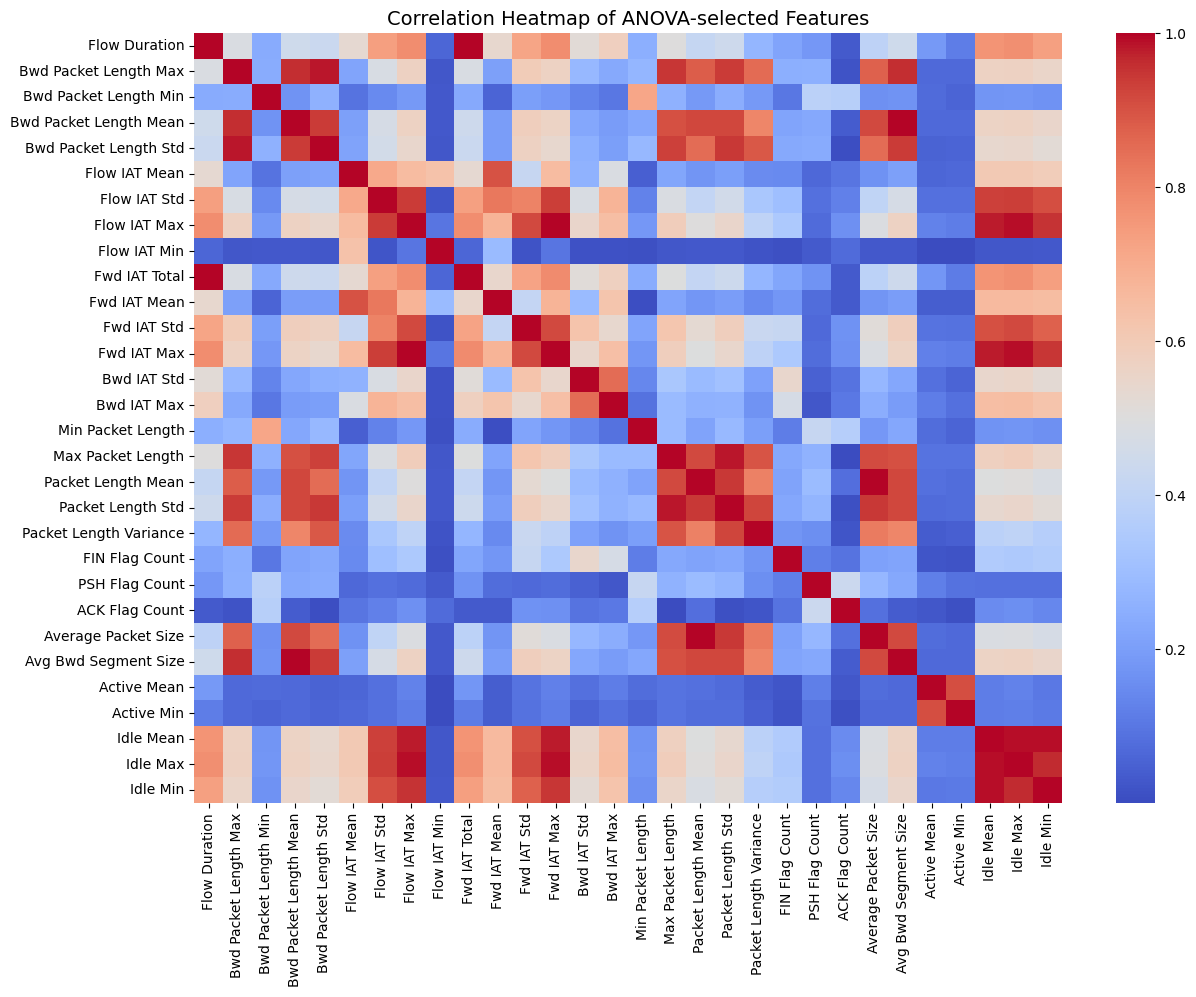

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

# Correlation matrix for ANOVA-selected features
plt.figure(figsize=(14,10))
sns.heatmap(corr_matrix, cmap="coolwarm", annot=False, cbar=True)

plt.title("Correlation Heatmap of ANOVA-selected Features", fontsize=14)
plt.show()


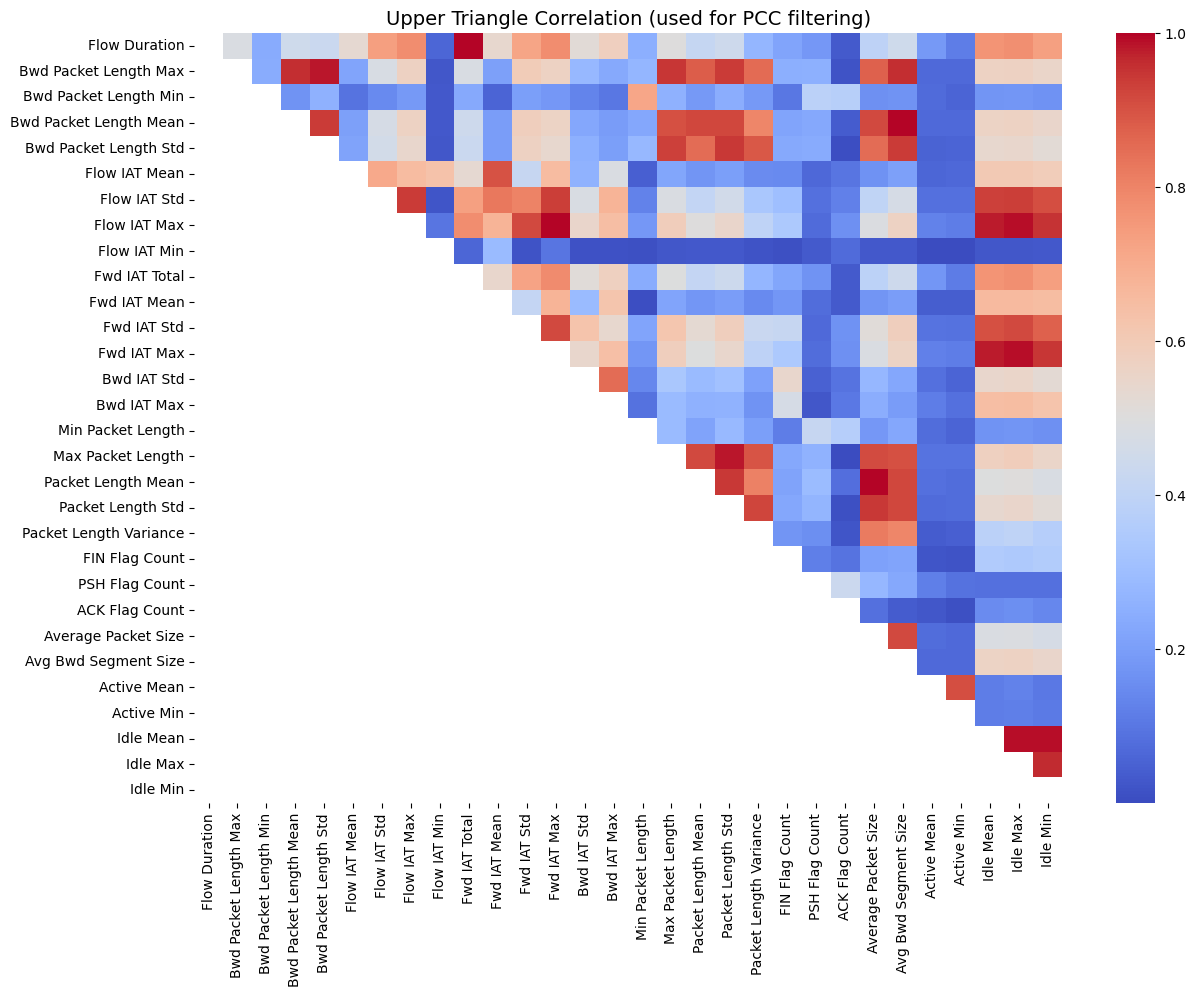

Dropped features due to high correlation (>0.9):
['Bwd Packet Length Mean', 'Bwd Packet Length Std', 'Flow IAT Max', 'Fwd IAT Total', 'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Max', 'Max Packet Length', 'Packet Length Mean', 'Packet Length Std', 'Packet Length Variance', 'Average Packet Size', 'Avg Bwd Segment Size', 'Active Min', 'Idle Mean', 'Idle Max', 'Idle Min']


In [16]:
# Mask upper triangle
plt.figure(figsize=(14,10))
sns.heatmap(upper, cmap="coolwarm", annot=False, cbar=True)

plt.title("Upper Triangle Correlation (used for PCC filtering)", fontsize=14)
plt.show()

print("Dropped features due to high correlation (>0.9):")
print(to_drop)


In [17]:
X_train_pcc

,Flow Duration,Bwd Packet Length Max,Bwd Packet Length Min,Flow IAT Mean,Flow IAT Std,Flow IAT Min,Bwd IAT Std,Bwd IAT Max,Min Packet Length,FIN Flag Count,PSH Flag Count,ACK Flag Count,Active Mean
0,14207.0,0.0,0.0,4.735667e+03,7.784866e+03,15.0,0.000000,14192.0,0.0,1.0,0.0,0.0,0.0
1,80824.0,297.0,0.0,1.347067e+04,2.019024e+04,4.0,22877.712710,40241.0,0.0,0.0,1.0,0.0,0.0
2,264896.0,109.0,109.0,3.784229e+04,8.705756e+04,2.0,134936.574498,233742.0,44.0,0.0,0.0,0.0,0.0
3,17996.0,0.0,0.0,8.998000e+03,1.272368e+04,1.0,0.000000,0.0,6.0,1.0,0.0,0.0,0.0
4,64895.0,124.0,124.0,6.489500e+04,0.000000e+00,64895.0,0.000000,0.0,53.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2017884,64051921.0,0.0,0.0,6.405192e+07,0.000000e+00,64051921.0,0.000000,0.0,37.0,0.0,0.0,1.0,0.0
2017885,5735370.0,2021.0,0.0,4.096693e+05,1.435530e+06,4.0,92804.209670,238424.0,0.0,0.0,1.0,0.0,342811.0
2017886,37.0,0.0,0.0,1.850000e+01,2.474874e+01,1.0,0.000000,0.0,0.0,0.0,0.0,1.0,0.0
2017887,42.0,6.0,6.0,4.200000e+01,0.000000e+00,42.0,0.000000,0.0,6.0,0.0,0.0,1.0,0.0


In [18]:
X_test_pcc

,Flow Duration,Bwd Packet Length Max,Bwd Packet Length Min,Flow IAT Mean,Flow IAT Std,Flow IAT Min,Bwd IAT Std,Bwd IAT Max,Min Packet Length,FIN Flag Count,PSH Flag Count,ACK Flag Count,Active Mean
0,5011280.0,0.0,0.0,1.252820e+06,2.500307e+06,1.0,0.00000,0.0,6.0,0.0,0.0,1.0,8003.0
1,23354.0,0.0,0.0,2.335400e+04,0.000000e+00,23354.0,0.00000,0.0,0.0,0.0,0.0,1.0,0.0
2,245295.0,6.0,6.0,6.132375e+04,1.226035e+05,1.0,2.12132,4.0,0.0,0.0,0.0,1.0,0.0
3,27.0,0.0,0.0,1.350000e+01,1.343503e+01,4.0,0.00000,0.0,0.0,0.0,0.0,1.0,0.0
4,69910.0,1448.0,0.0,8.738750e+03,1.491772e+04,1.0,17225.84955,35135.0,0.0,0.0,1.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
504468,113095.0,185.0,185.0,1.130950e+05,0.000000e+00,113095.0,0.00000,0.0,45.0,0.0,0.0,0.0,0.0
504469,57.0,6.0,6.0,5.700000e+01,0.000000e+00,57.0,0.00000,0.0,0.0,0.0,1.0,0.0,0.0
504470,42.0,6.0,6.0,4.200000e+01,0.000000e+00,42.0,0.00000,0.0,6.0,0.0,0.0,1.0,0.0
504471,197994.0,1451.0,0.0,9.428286e+03,1.720968e+04,1.0,25357.15807,67431.0,0.0,0.0,1.0,0.0,0.0


#### EMBEDDED METHOD

                  Feature  Importance
1   Bwd Packet Length Max    0.216988
0           Flow Duration    0.147065
4            Flow IAT Std    0.138360
3           Flow IAT Mean    0.072746
2   Bwd Packet Length Min    0.070606
7             Bwd IAT Max    0.068824
10         PSH Flag Count    0.067629
6             Bwd IAT Std    0.049101
9          FIN Flag Count    0.047212
8       Min Packet Length    0.040718
5            Flow IAT Min    0.034472
11         ACK Flag Count    0.031747
12            Active Mean    0.014531


C:\Users\vp532\AppData\Local\Temp\ipykernel_26888\1860033022.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Importance", y="Feature", data=feat_importances, palette="viridis")


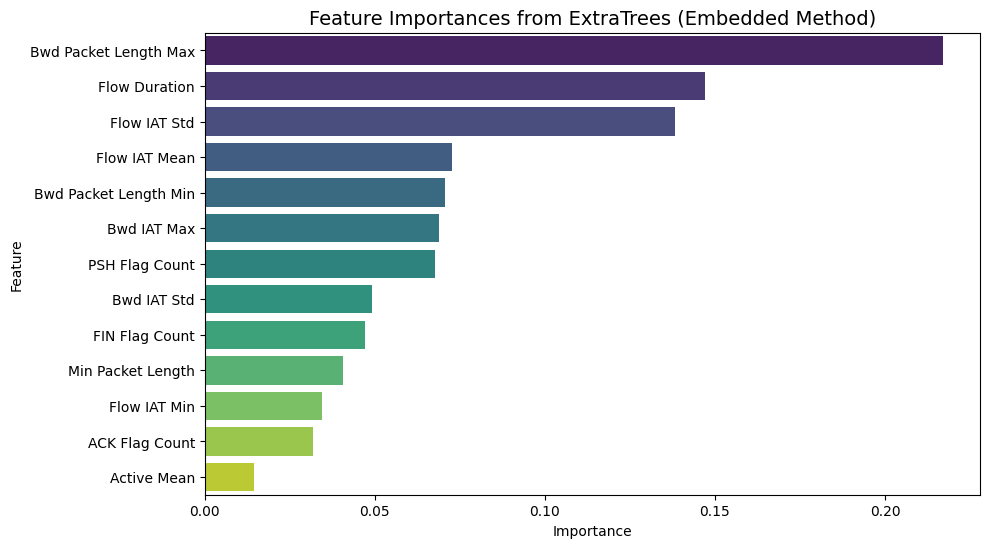

In [19]:
from sklearn.ensemble import ExtraTreesClassifier
import matplotlib.pyplot as plt
import seaborn as sns

# Train ExtraTrees on the reduced feature set (13 features)
model = ExtraTreesClassifier(n_estimators=200, random_state=42)
model.fit(X_train_pcc, y_train)

# Get feature importances
importances = model.feature_importances_
features = X_train_pcc.columns

# Create DataFrame for easy viewing
feat_importances = pd.DataFrame({"Feature": features, "Importance": importances})
feat_importances = feat_importances.sort_values(by="Importance", ascending=False)

print(feat_importances)

# Visualization
plt.figure(figsize=(10,6))
sns.barplot(x="Importance", y="Feature", data=feat_importances, palette="viridis")
plt.title("Feature Importances from ExtraTrees (Embedded Method)", fontsize=14)
plt.show()


In [20]:
from sklearn.preprocessing import MinMaxScaler

# Choose final feature set (drop 'Active Mean' if you want)
final_features = feat_importances[feat_importances['Importance'] > 0.02]['Feature'].tolist()
# OR keep all 13
# final_features = feat_importances['Feature'].tolist()

print("Final selected features:", final_features)

# Apply Min-Max scaling on final features
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train_pcc[final_features])
X_test_scaled = scaler.transform(X_test_pcc[final_features])

# Convert back to DataFrames for saving
X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=final_features)
X_test_scaled_df = pd.DataFrame(X_test_scaled, columns=final_features)

# Add target column back
train_processed = X_train_scaled_df.copy()
train_processed['label_multi_enc'] = y_train.reset_index(drop=True)

test_processed = X_test_scaled_df.copy()
test_processed['label_multi_enc'] = y_test.reset_index(drop=True)

# Combine for saving full processed dataset
processed = pd.concat([train_processed, test_processed], axis=0)

# Save processed dataset
processed.to_csv("CICIDS_multiclass_processed.csv", index=False)

print("✅ Saved processed dataset as CICIDS_multiclass_processed.csv")
print("Shape:", processed.shape)


Final selected features: ['Bwd Packet Length Max', 'Flow Duration', 'Flow IAT Std', 'Flow IAT Mean', 'Bwd Packet Length Min', 'Bwd IAT Max', 'PSH Flag Count', 'Bwd IAT Std', 'FIN Flag Count', 'Min Packet Length', 'Flow IAT Min', 'ACK Flag Count']
✅ Saved processed dataset as CICIDS_multiclass_processed.csv
Shape: (2522362, 13)
